In [1]:
import pandas as pd
import pypsa

RESULT_FILE = "tamil_nadu_2025_26_15min.nc"
n = pypsa.Network(RESULT_FILE)

assert len(n.snapshots) == 672, f"Expected 672 quarter-hour snapshots, found {len(n.snapshots)}"
assert (n.snapshots.to_series().diff().dropna() == pd.Timedelta(minutes=15)).all()
assert (n.snapshot_weightings[["objective", "stores", "generators"]] == 0.25).all().all()
print(f"Loaded solved 15-minute peak week from {RESULT_FILE}")

INFO:pypsa.network.io:Imported network 'Tamil Nadu FY 2025-26 single-node UC inputs (15-minute)' has buses, carriers, generators, loads, storage_units, sub_networks


Loaded solved 15-minute peak week from tamil_nadu_2025_26_15min.nc


In [2]:
n

PyPSA Network 'Tamil Nadu FY 2025-26 single-node UC inputs (15-minute)'
-----------------------------------------------------------------------
Components:
 - Bus: 1
 - Carrier: 12
 - Generator: 278
 - Load: 1
 - StorageUnit: 4
 - SubNetwork: 1
Snapshots: 672

## Dispatch, storage, and coal commitment

This four-panel figure shows how supply meets demand during the peak-demand week at 15-minute resolution:

1. **Total system dispatch:** The stacked areas show generation and storage discharge by carrier. The height of the stack is total supply, while the black line is demand. Coal is grey, solar yellow, wind light blue, hydro blue, and unserved energy red. A visible red area would indicate that available supply could not fully meet demand.
2. **Total storage operation:** The graph aggregates all storage units. The positive line is total discharge supplied to the system, while the negative line is total charging demand. Keeping the two totals separate preserves any simultaneous charging and discharging by different units.
3. **Total storage state of charge:** This is the sum of the energy held in all storage units in MWh. Rising values indicate net charging and falling values indicate net discharge.
4. **Coal unit commitment:** The grey line and left axis show total coal generation in MW. The dashed red line and right axis show the percentage of coal units that are online. This percentage is based on the number of units, not their installed capacity.


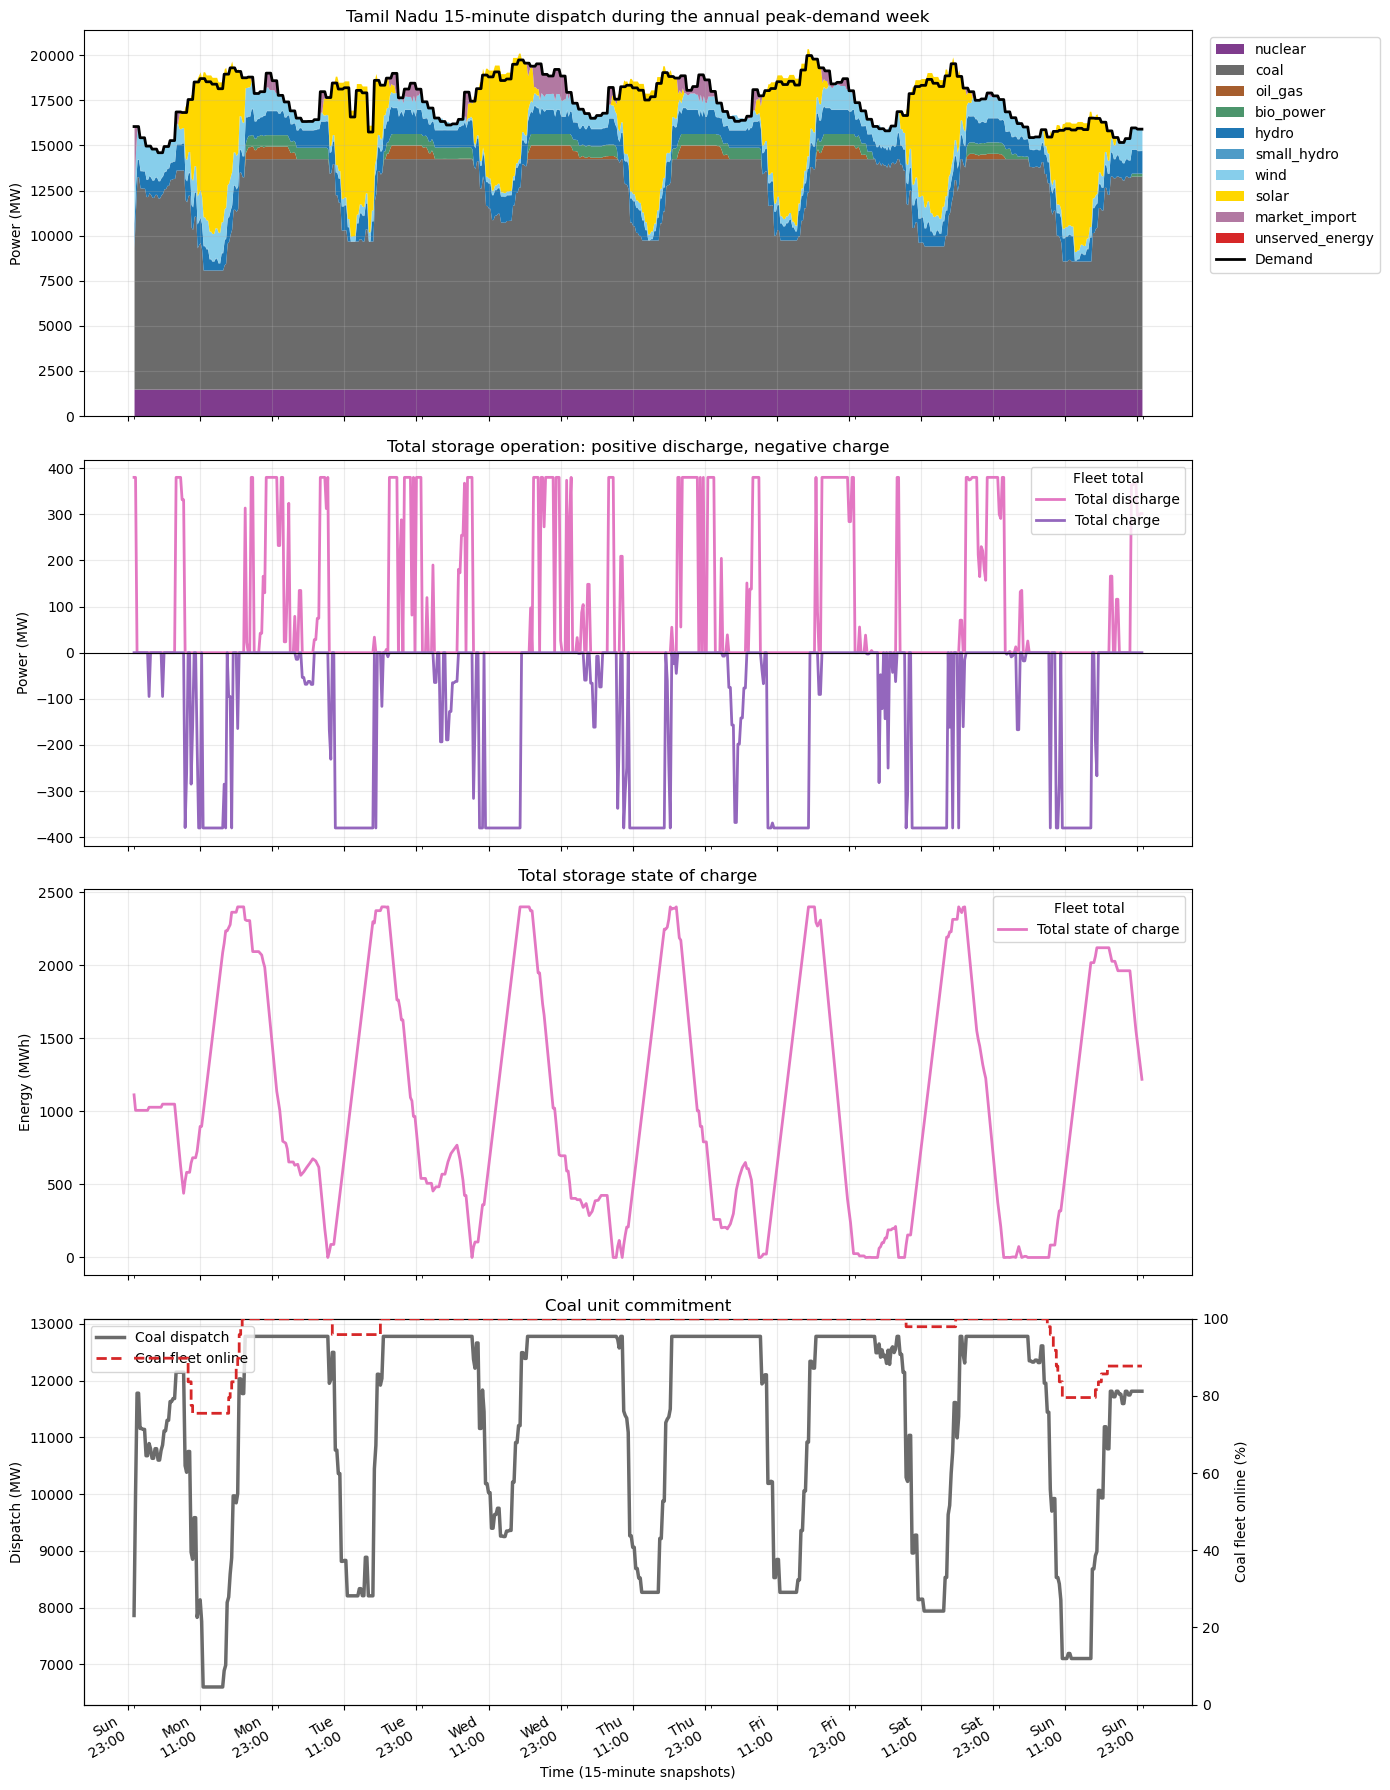

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n

# Intuitive, consistent carrier colors used throughout the analysis
carrier_colors = {
    "nuclear": "#7F3C8D",       # purple
    "coal": "#6B6B6B",          # grey
    "oil_gas": "#A65E2E",       # brown
    "bio_power": "#4C956C",     # green
    "hydro": "#1F77B4",         # blue
    "small_hydro": "#4E9BC7",   # medium blue
    "wind": "#87CEEB",          # light blue
    "solar": "#FFD700",         # yellow
    "market_import": "#B279A2", # mauve
    "battery": "#E377C2",       # pink
    "unserved_energy": "#D62728",  # red
}

# Aggregate generator dispatch by carrier
generation = (
    n.generators_t.p
    .T.groupby(n.generators["carrier"])
    .sum().T
    .clip(lower=0)
)

# Storage: positive = discharge, negative = charge
storage_power = n.storage_units_t.p
storage_discharge = (
    storage_power.clip(lower=0)
    .T.groupby(n.storage_units["carrier"])
    .sum().T
)

supply = generation.add(storage_discharge, fill_value=0)
demand = n.loads_t.p_set.sum(axis=1)

carrier_order = [
    "nuclear", "coal", "oil_gas", "bio_power", "hydro",
    "small_hydro", "wind", "solar", "market_import",
    "battery", "unserved_energy",
]
carrier_order = [c for c in carrier_order if c in supply.columns]
supply = supply[carrier_order]

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

# 1. Total system dispatch
supply.plot.area(
    ax=axes[0], stacked=True, linewidth=0,
    color=[carrier_colors[carrier] for carrier in supply.columns],
    x_compat=True,
)
demand.plot(
    ax=axes[0], color="black", linewidth=2, label="Demand", x_compat=True
)
axes[0].set_title("Tamil Nadu 15-minute dispatch during the annual peak-demand week")
axes[0].set_ylabel("Power (MW)")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1))

# 2. Total storage charge and discharge across all units
storage_operation = pd.DataFrame({
    "Total discharge": storage_power.clip(lower=0).sum(axis=1),
    "Total charge": storage_power.clip(upper=0).sum(axis=1),
})
storage_operation.plot(
    ax=axes[1], linewidth=2, color=[carrier_colors["battery"], "#9467BD"],
    x_compat=True,
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Total storage operation: positive discharge, negative charge")
axes[1].set_ylabel("Power (MW)")
axes[1].legend(title="Fleet total")

# 3. Total storage state of charge across all units
total_soc = n.storage_units_t.state_of_charge.sum(axis=1)
total_soc.plot(
    ax=axes[2], linewidth=2, color=carrier_colors["battery"],
    label="Total state of charge", x_compat=True,
)
axes[2].set_title("Total storage state of charge")
axes[2].set_ylabel("Energy (MWh)")
axes[2].legend(title="Fleet total")

# 4. Coal dispatch and committed record-level units
coal_units = n.generators.index[n.generators.carrier == "coal"]
coal_dispatch = n.generators_t.p[coal_units].sum(axis=1)
coal_online_pct = 100 * n.generators_t.status[coal_units].sum(axis=1) / len(coal_units)

coal_dispatch.plot(
    ax=axes[3], color=carrier_colors["coal"], linewidth=2.5,
    label="Coal dispatch", zorder=3, x_compat=True,
)
axes[3].set_title("Coal unit commitment")
axes[3].set_ylabel("Dispatch (MW)")

commitment_axis = axes[3].twinx()
coal_online_pct.plot(
    ax=commitment_axis, drawstyle="steps-post", color="tab:red",
    linewidth=2, linestyle="--", label="Coal fleet online",
    zorder=4, x_compat=True,
)
commitment_axis.set_ylabel("Coal fleet online (%)")
commitment_axis.set_ylim(0, 100)

lines1, labels1 = axes[3].get_legend_handles_labels()
lines2, labels2 = commitment_axis.get_legend_handles_labels()
axes[3].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=12))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
axes[3].set_xlabel("Time (15-minute snapshots)")
axes[3].grid(alpha=0.25)

for ax in axes[:3]:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Evening flexibility and ramp adequacy

Net load is demand minus wind and solar generation. Its increase between consecutive snapshots is the response that dispatchable generators and storage must provide. For committable generators, the calculation below reproduces PyPSA's applicable upward-ramp allowance: the normal ramp limit for units already online and the start-up ramp limit for units starting in that interval.

> **Resolution limitation:** the supplied demand and renewable availability are constant within each group of four quarter-hours and change only on the hour. Consequently, an entire hourly change occurs at one 15-minute boundary. The resulting MW/15-minute ramps are a conservative step-change stress test, not observed intra-hour variability. True 15-minute demand and renewable profiles are required for an empirical flexibility assessment.

In [4]:
vre_carriers = ["solar", "wind"]
dispatchable_carriers = [
    "coal", "oil_gas", "bio_power", "hydro",
    "small_hydro", "market_import",
]

generation_by_carrier = (
    n.generators_t.p.T.groupby(n.generators.carrier).sum().T.clip(lower=0)
)
vre_generation = generation_by_carrier.reindex(columns=vre_carriers, fill_value=0).sum(axis=1)
net_load = demand - vre_generation
net_load_ramp = net_load.diff()  # MW change between consecutive 15-minute averages

dispatchable_generation = generation_by_carrier.reindex(
    columns=dispatchable_carriers, fill_value=0
).sum(axis=1)
storage_response = n.storage_units_t.p.sum(axis=1)
dispatchable_response = dispatchable_generation + storage_response
dispatchable_response_ramp = dispatchable_response.diff()

# Reconstruct the exact upward allowance used for fixed-capacity committable units.
ramp_units = n.generators.index[
    n.generators.committable & n.generators.ramp_limit_up.notna()
]
unit_dispatch = n.generators_t.p[ramp_units]
unit_status = n.generators_t.status[ramp_units].round()
previous_dispatch = unit_dispatch.shift(1)
previous_status = unit_status.shift(1)
unit_increase = unit_dispatch - previous_dispatch
status_change = unit_status - previous_status

p_nom = n.generators.loc[ramp_units, "p_nom"]
normal_up = n.generators.loc[ramp_units, "ramp_limit_up"]
start_up = n.generators.loc[ramp_units, "ramp_limit_start_up"]
allowed_up = (
    previous_status.mul(p_nom * normal_up, axis=1)
    + status_change.mul(p_nom * start_up, axis=1)
)
upward_ramp_utilization = unit_increase.where(unit_increase > 1e-6).div(
    allowed_up.where(allowed_up > 0)
)
binding_up_units = upward_ramp_utilization.ge(0.95).sum(axis=1)
starting_units = status_change.gt(0.5).sum(axis=1)
max_up_utilization = upward_ramp_utilization.max(axis=1).clip(upper=1.0)

unserved = generation_by_carrier.get(
    "unserved_energy", pd.Series(0.0, index=n.snapshots)
)
unserved_mwh = (unserved * n.snapshot_weightings.generators).sum()
evening = net_load_ramp.index.hour.isin(range(15, 22))
peak_ramp_time = net_load_ramp.loc[evening].idxmax()

print(f"Largest evening net-load increase: {net_load_ramp.at[peak_ramp_time]:,.1f} MW/15 min "
      f"({4 * net_load_ramp.at[peak_ramp_time]:,.1f} MW/h equivalent) at {peak_ramp_time}")
print(f"Dispatchable response in that interval: "
      f"{dispatchable_response_ramp.at[peak_ramp_time]:,.1f} MW")
print(f"Thermal units starting: {starting_units.at[peak_ramp_time]:.0f}; "
      f"at or above 95% of upward ramp allowance: {binding_up_units.at[peak_ramp_time]:.0f}")
print(f"Unserved energy over the week: {unserved_mwh:,.3f} MWh")
print("Demand changes away from hourly boundaries:",
      int((demand.diff().abs() > 1e-9)[demand.index.minute != 0].sum()))
print("Solar/wind changes away from hourly boundaries:",
      int((vre_generation.diff().abs() > 1e-9)[vre_generation.index.minute != 0].sum()))

Largest evening net-load increase: 2,866.8 MW/15 min (11,467.2 MW/h equivalent) at 2025-07-08 16:00:00
Dispatchable response in that interval: 2,866.8 MW
Thermal units starting: 0; at or above 95% of upward ramp allowance: 47
Unserved energy over the week: 0.000 MWh
Demand changes away from hourly boundaries: 0
Solar/wind changes away from hourly boundaries: 167


### How to read the flexibility and ramp graphs

This three-panel figure examines whether dispatchable generation and storage can follow rapid changes in net load:

1. **Demand, renewables, and net load:** Demand is the black line. Wind and solar generation are combined in the orange line. Net load is demand minus wind and solar, so the purple line represents the demand that must be met by dispatchable generators, imports, and storage.
2. **System ramp requirement and response:** The purple line is the change in net load between consecutive 15-minute snapshots, multiplied by four to express an equivalent hourly ramp rate. Positive values require supply to increase; negative values require it to decrease. The dashed green line shows the corresponding response from dispatchable generators and storage.
3. **Unit ramp utilization:** The red line and left axis show the highest share of any committed unit's applicable upward-ramp allowance used in each interval. The dotted 95% line highlights intervals close to the modeled limit. The blue stepped line and right axis count units at or above 95% utilization. Yellow shading marks the 15:00–21:00 evening period, when solar output falls and flexibility is especially important.

Because the underlying demand and renewable inputs change only on the hour, the 15-minute ramp graph represents conservative step changes rather than observed intra-hour variation.


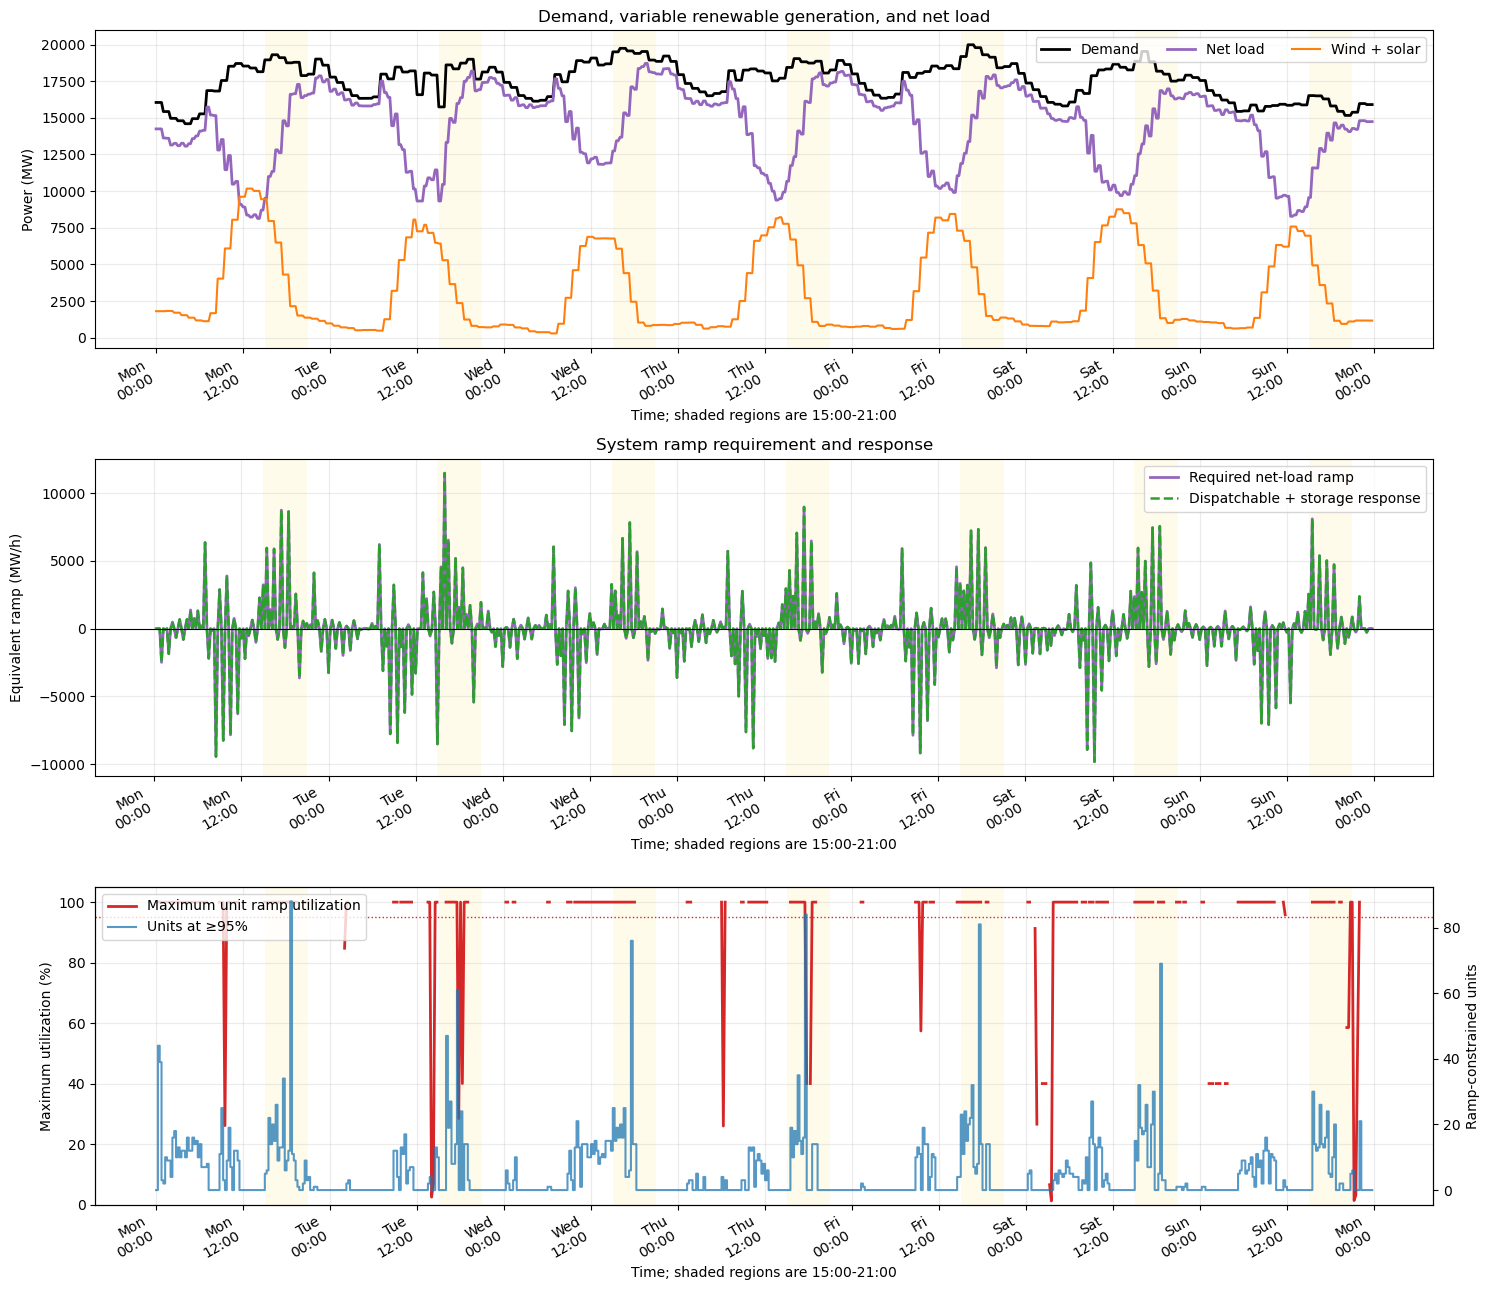

In [5]:
fig, ramp_axes = plt.subplots(3, 1, figsize=(15, 13), sharex=False)

demand.plot(ax=ramp_axes[0], color="black", linewidth=2, label="Demand", x_compat=True)
net_load.plot(ax=ramp_axes[0], color="tab:purple", linewidth=2, label="Net load", x_compat=True)
vre_generation.plot(ax=ramp_axes[0], color="tab:orange", label="Wind + solar", x_compat=True)
ramp_axes[0].set_ylabel("Power (MW)")
ramp_axes[0].set_title("Demand, variable renewable generation, and net load")
ramp_axes[0].legend(ncol=3)

(4 * net_load_ramp).plot(
    ax=ramp_axes[1], color="tab:purple", linewidth=2,
    label="Required net-load ramp", x_compat=True,
)
(4 * dispatchable_response_ramp).plot(
    ax=ramp_axes[1], color="tab:green", linestyle="--", linewidth=1.8,
    label="Dispatchable + storage response", x_compat=True,
)
ramp_axes[1].axhline(0, color="black", linewidth=0.8)
ramp_axes[1].set_ylabel("Equivalent ramp (MW/h)")
ramp_axes[1].set_title("System ramp requirement and response")
ramp_axes[1].legend()

(100 * max_up_utilization).plot(
    ax=ramp_axes[2], color="tab:red", linewidth=2,
    label="Maximum unit ramp utilization", x_compat=True,
)
ramp_axes[2].axhline(95, color="tab:red", linestyle=":", linewidth=1)
ramp_axes[2].set_ylim(0, 105)
ramp_axes[2].set_ylabel("Maximum utilization (%)")
binding_axis = ramp_axes[2].twinx()
binding_up_units.plot(
    ax=binding_axis, color="tab:blue", drawstyle="steps-post",
    alpha=0.75, label="Units at ≥95%", x_compat=True,
)
binding_axis.set_ylabel("Ramp-constrained units")

for day in pd.DatetimeIndex(n.snapshots.normalize().unique()):
    for ax in ramp_axes:
        ax.axvspan(
            day + pd.Timedelta(hours=15), day + pd.Timedelta(hours=21),
            color="gold", alpha=0.08, linewidth=0,
        )
for ax in ramp_axes:
    ax.grid(alpha=0.25)

lines1, labels1 = ramp_axes[2].get_legend_handles_labels()
lines2, labels2 = binding_axis.get_legend_handles_labels()
ramp_axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper left")
tick_positions = pd.date_range(
    n.snapshots[0].normalize(), n.snapshots[-1].ceil("12h"), freq="12h"
)
for ax in ramp_axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([timestamp.strftime("%a\n%H:%M") for timestamp in tick_positions])
    ax.set_xlabel("Time; shaded regions are 15:00-21:00")
plt.tight_layout()
plt.show()

In [6]:
carrier_ramps = generation_by_carrier.reindex(
    columns=dispatchable_carriers, fill_value=0
).diff()
interval_summary = pd.DataFrame({
    "net_load_ramp_mw_per_15min": net_load_ramp,
    "equivalent_mw_per_hour": 4 * net_load_ramp,
    "dispatchable_response_mw": dispatchable_response_ramp,
    "coal_response_mw": carrier_ramps["coal"],
    "oil_gas_response_mw": carrier_ramps["oil_gas"],
    "bio_power_response_mw": carrier_ramps["bio_power"],
    "hydro_response_mw": carrier_ramps["hydro"],
    "storage_response_mw": storage_response.diff(),
    "thermal_startups": starting_units,
    "units_at_or_above_95pct_ramp": binding_up_units,
    "unserved_energy_mw": unserved,
})

print("Largest late-afternoon/evening system ramps:")
display(interval_summary.loc[evening].nlargest(10, "net_load_ramp_mw_per_15min").round(2))

unit_events = pd.DataFrame({
    "actual_increase_mw": unit_increase.stack(),
    "allowed_increase_mw": allowed_up.stack(),
    "ramp_utilization": upward_ramp_utilization.stack(),
}).dropna()
unit_events = unit_events.loc[unit_events.actual_increase_mw > 1e-6].reset_index()
unit_events.columns = ["snapshot", "generator", *unit_events.columns[2:]]
unit_events["carrier"] = unit_events.generator.map(n.generators.carrier)
unit_events["started"] = [
    bool(status_change.at[timestamp, generator] > 0.5)
    for timestamp, generator in zip(unit_events.snapshot, unit_events.generator)
]
unit_events["ramp_utilization_pct"] = (100 * unit_events.ramp_utilization).clip(upper=100)
largest_binding_events = (
    unit_events.loc[unit_events.ramp_utilization >= 0.95]
    .sort_values("actual_increase_mw", ascending=False)
    .drop(columns=["ramp_utilization"])
    .head(20)
)
print("Largest individual increases at or above 95% of the applicable ramp limit:")
display(largest_binding_events.round(2))

Largest late-afternoon/evening system ramps:


,net_load_ramp_mw_per_15min,equivalent_mw_per_hour,dispatchable_response_mw,coal_response_mw,oil_gas_response_mw,bio_power_response_mw,hydro_response_mw,storage_response_mw,thermal_startups,units_at_or_above_95pct_ramp,unserved_energy_mw
snapshot,,,,,,,,,,,
2025-07-08 16:00:00,2866.81,11467.24,2866.81,2238.08,0.00,0.00,216.57,413.62,0,47,0.0
2025-07-10 17:30:00,2242.19,8968.76,2242.19,1279.48,0.00,527.56,0.00,435.15,57,84,0.0
2025-07-07 17:30:00,2184.35,8737.39,2184.35,2019.84,0.00,0.00,0.00,164.51,3,34,0.0
2025-07-07 18:30:00,2158.18,8632.72,2158.18,1007.71,309.43,527.56,0.00,313.48,69,88,0.0
2025-07-13 15:30:00,2024.39,8097.57,2024.39,1578.13,0.00,0.00,66.27,380.00,0,30,0.0
2025-07-09 17:30:00,1954.50,7817.99,1954.50,388.23,337.83,527.56,0.00,0.00,71,76,0.0
2025-07-12 18:30:00,1885.88,7543.53,1885.88,469.68,131.46,527.56,0.00,395.48,60,69,0.0
2025-07-12 17:30:00,1861.36,7445.43,1861.36,1410.91,0.00,0.00,0.00,450.45,0,30,0.0
2025-07-11 17:30:00,1831.44,7325.77,1831.44,559.61,337.83,527.56,0.00,380.00,71,81,0.0


Largest individual increases at or above 95% of the applicable ramp limit:


,snapshot,generator,actual_increase_mw,allowed_increase_mw,carrier,started,ramp_utilization_pct
629,2025-07-07 17:00:00,muthiara_tpp__unit_01,330.00,330.00,coal,True,100.0
3360,2025-07-12 16:45:00,north_chennai_tps__unit_04,330.00,330.00,coal,True,100.0
650,2025-07-07 17:15:00,tuticorin_thermal_power_plant__unit_01,288.75,288.75,coal,True,100.0
3924,2025-07-13 16:00:00,tuticorin_joint_venture__unit_02,275.00,275.00,coal,True,100.0
660,2025-07-07 17:30:00,neyveli_new_tpp_neyveli_extension__unit_01,275.00,275.00,coal,True,100.0
3096,2025-07-12 08:45:00,north_chennai_tps__unit_06,120.00,120.00,coal,False,100.0
3381,2025-07-12 17:15:00,north_chennai_tps__unit_06,120.00,120.00,coal,False,100.0
1481,2025-07-09 11:00:00,north_chennai_tps__unit_06,120.00,120.00,coal,False,100.0
2740,2025-07-11 16:30:00,north_chennai_tps__unit_06,120.00,120.00,coal,False,100.0
2051,2025-07-10 09:45:00,north_chennai_tps__unit_06,120.00,120.00,coal,False,100.0
